FEATURE ENGINEERING


In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score


df= pd.read_csv("data collections/melb_data.csv")
df= df.dropna(axis=0)
df.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0
6,Abbotsford,124 Yarra St,3,h,1876000.0,S,Nelson,7/05/2016,2.5,3067.0,...,2.0,0.0,245.0,210.0,1910.0,Yarra,-37.8024,144.9993,Northern Metropolitan,4019.0
7,Abbotsford,98 Charles St,2,h,1636000.0,S,Nelson,8/10/2016,2.5,3067.0,...,1.0,2.0,256.0,107.0,1890.0,Yarra,-37.8060,144.9954,Northern Metropolitan,4019.0


In [46]:

features= ['Rooms', 'Bathroom', 'Landsize', 'BuildingArea', 'YearBuilt', 'Lattitude', 'Longtitude']
X = df[features]

y = df['Price']




baseline = RandomForestRegressor(criterion="absolute_error", random_state=0)
baseline_score = cross_val_score(
    baseline, X, y, cv=5, scoring="neg_mean_absolute_error", error_score='raise'
)
baseline_score = -1 * baseline_score.mean()

print(f"MAE Baseline Score: {baseline_score:.4}")



MAE Baseline Score: 1.939e+05


In [47]:
features= ['Rooms', 'Bathroom', 'Landsize', 'BuildingArea', 'YearBuilt', 'Lattitude', 'Longtitude']
X = df[features]

y = df['Price']

X['TotalArea'] = X['BuildingArea'] + X['Landsize']
X['RoomSizeAvarage'] = X['BuildingArea'] / X['Rooms']
# 1. Definiera centrum (exempel: Melbourne CBD)
cbd_lat, cbd_lon = -37.8136, 144.9631

# 2. Beräkna euklidiskt avstånd (Pythagoras sats)
X['Dist_to_CBD'] = ((X['Lattitude'] - cbd_lat)**2 + (X['Longtitude'] - cbd_lon)**2)**0.5

baseline = RandomForestRegressor(criterion="absolute_error", random_state=0)
baseline_score = cross_val_score(
    baseline, X, y, cv=5, scoring="neg_mean_absolute_error", error_score='raise'
)
baseline_score = -1 * baseline_score.mean()

print(f"MAE Baseline Score: {baseline_score:.4}")

MAE Baseline Score: 1.907e+05


In [48]:
y

1        1035000.0
2        1465000.0
4        1600000.0
6        1876000.0
7        1636000.0
           ...    
12205     601000.0
12206    1050000.0
12207     385000.0
12209     560000.0
12212    2450000.0
Name: Price, Length: 6196, dtype: float64

In [49]:
features= ['Rooms', 'Bathroom', 'Landsize', 'BuildingArea', 'YearBuilt', 'Lattitude', 'Longtitude']
X = df[features]

y = df['Price']

X['TotalArea'] = X['BuildingArea'] + X['Landsize']
X['RoomSizeAvarage'] = X['BuildingArea'] / X['Rooms']
# 1. Definiera centrum (exempel: Melbourne CBD)
cbd_lat, cbd_lon = -37.8136, 144.9631

# 2. Beräkna euklidiskt avstånd (Pythagoras sats)
X['Dist_to_CBD'] = ((X['Lattitude'] - cbd_lat)**2 + (X['Longtitude'] - cbd_lon)**2)**0.5


# Label encoding for categoricals
for colname in X.select_dtypes("object"):
    X[colname], _ = X[colname].factorize()

# All discrete features should now have integer dtypes (double-check this before using MI!)
discrete_features = X.dtypes == int

X.describe().dtypes

Rooms              float64
Bathroom           float64
Landsize           float64
BuildingArea       float64
YearBuilt          float64
Lattitude          float64
Longtitude         float64
TotalArea          float64
RoomSizeAvarage    float64
Dist_to_CBD        float64
dtype: object

In [50]:
from sklearn.feature_selection import mutual_info_regression

def make_mi_scores(X, y, discrete_features):
    mi_scores = mutual_info_regression(X, y, discrete_features=discrete_features)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores

mi_scores = make_mi_scores(X, y, discrete_features)
mi_scores[::]  # show a few features with their MI scores

BuildingArea       0.398111
TotalArea          0.269419
Rooms              0.259821
Bathroom           0.172516
Landsize           0.165535
YearBuilt          0.157400
Lattitude          0.148651
Longtitude         0.147200
RoomSizeAvarage    0.115344
Dist_to_CBD        0.074524
Name: MI Scores, dtype: float64

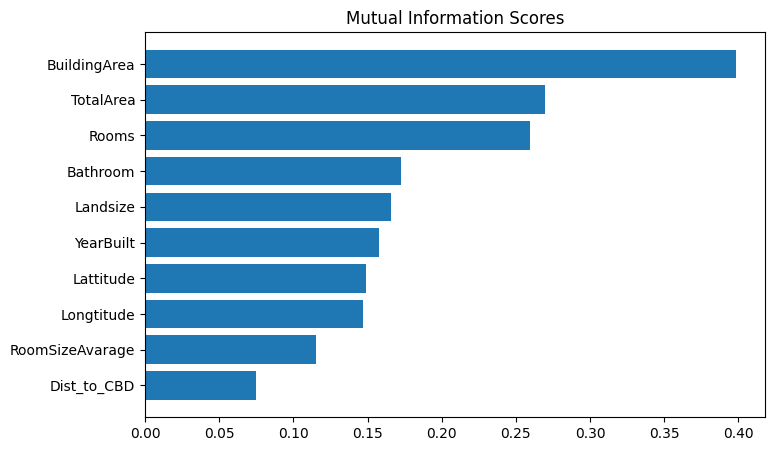

In [51]:
def plot_mi_scores(scores):
    scores = scores.sort_values(ascending=True)
    width = np.arange(len(scores))
    ticks = list(scores.index)
    plt.barh(width, scores)
    plt.yticks(width, ticks)
    plt.title("Mutual Information Scores")

plt.figure(dpi=100, figsize=(8, 5))
plot_mi_scores(mi_scores)

Text(0.5, 1.0, 'hus')

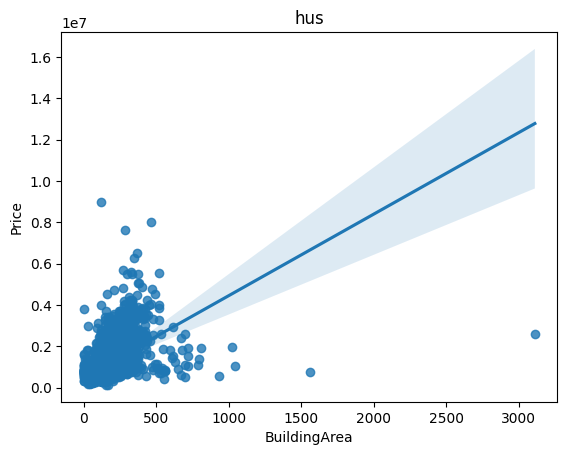

In [52]:
sns.regplot(data=df, x='BuildingArea', y='Price')
plt.title("hus")

Clustering with kmeans, (unsupervised learning) re scaling is important bucause if the target is more dependent towards the other feature which is usually smaller in numbers the clustering will be misleading for a accurate target prediction.

In [116]:
from sklearn.cluster import KMeans
from sklearn.model_selection import cross_val_score
from xgboost import XGBRegressor as xgb
from sklearn.preprocessing import MinMaxScaler

#apparently xgb handles large numbers well but benifits fitting smaller numbers compared to extremely large ones so its better to use y_log = np.log1p(y) #y_log= target #original scale= np.expm1(y_log)

#y= np.log1p(df['Price'])


#print(np.expm1(y))


X=df.loc[:, ['Price', 'Lattitude', 'Longtitude']]
#y['Price']= np.expm1(df['Price'])
X.head()


,Price,Lattitude,Longtitude
1,1035000.0,-37.8079,144.9934
2,1465000.0,-37.8093,144.9944
4,1600000.0,-37.8072,144.9941
6,1876000.0,-37.8024,144.9993
7,1636000.0,-37.8060,144.9954


In [131]:
kmeans = KMeans(n_clusters=6)
X["Cluster"] = kmeans.fit_predict(X)
#X["Cluster"] = X["Cluster"].astype("category")

X.head()


,Price,Lattitude,Longtitude,Cluster
1,1035000.0,-37.8079,144.9934,1
2,1465000.0,-37.8093,144.9944,4
4,1600000.0,-37.8072,144.9941,2
6,1876000.0,-37.8024,144.9993,2
7,1636000.0,-37.8060,144.9954,2


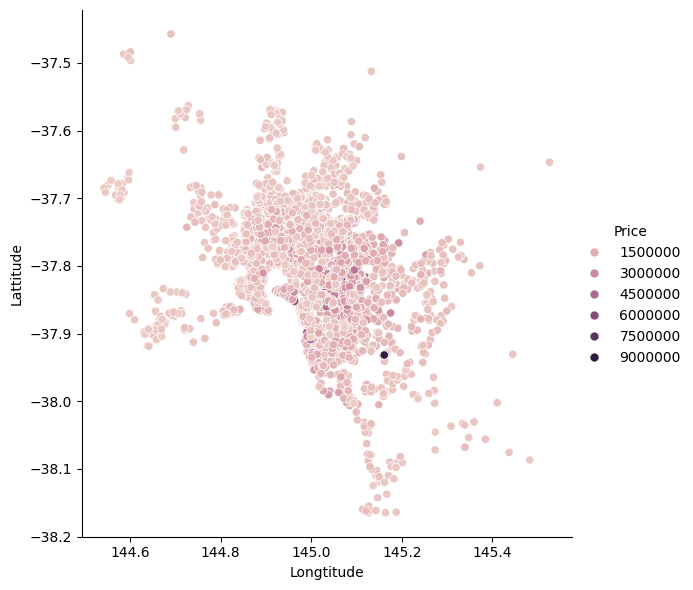

: 

In [ ]:
sns.relplot(
    x="Longtitude", y="Lattitude", hue="Price", data=X, height=6,
);